# 1. Fractions, percentages, and exponents: read the numbers behind ML

Learn to interpret a fraction as a ratio, convert between fractions and percentages, distinguish percentage points from relative changes, and calculate powers. Prerequisite: basic Python arithmetic from the [Python foundations](../../../01_Python_Foundations/README.md). You will use a small invented classification result and squared numerical errors. You do not need to know how a model is trained yet.

By the end you should explain the denominator behind a reported score and reproduce each hand calculation in Python. A numerical result needs both a calculation and a statement of what was counted. A percentage without that statement can conceal a very different question.

## 2. What problem does this solve?

Machine learning reports often contain statements such as '75 percent accuracy' or 'loss fell by 20 percent.' Those statements summarize measurements. Before studying algorithms, we need to understand ratios and changes well enough to interpret them critically.

We will count correct predictions among a known number of examples. Later we will square small prediction errors. These exercises connect elementary arithmetic to evaluation without assuming that a score by itself makes a model useful. Accuracy can be a poor choice for some tasks; here it is simply a clear ratio to learn from.

## 3. Intuition and analogy

Imagine sharing a cake cut into eight equal pieces. Six pieces represent six eighths of the whole. Simplifying six eighths to three quarters changes the notation, not the amount. A percentage asks how much that same share would occupy if the whole were represented by one hundred equal parts.

An exponent means repeated multiplication for positive whole-number powers. Squaring an error of two multiplies two by itself. The sign matters: squaring negative two gives positive four. Parentheses tell Python whether a negative sign belongs inside the power operation or is applied afterward.

## 4. Terminology

In a fraction $a/b$, $a$ is the **numerator** and $b$ is the **denominator**; $b$ must not be zero. A **ratio** compares quantities by division. A **proportion** is a part divided by its whole. **Percent** means per hundred. A **percentage point** is a difference between two percentages expressed on the hundred-point scale.

In $u^k$, $u$ is the **base** and $k$ is the **exponent**. A **square** is a second power; a **cube** is a third power. In Python, `**` raises a power; `^` is a bitwise operator and is not exponentiation. `/` performs division. `Fraction` represents an exact rational number rather than a binary floating-point approximation.

## 5. Mathematical foundations

If $c$ predictions are correct among $n>0$ evaluated examples, the correct fraction and percentage are

$$p=c/n,\qquad P=100p.$$

$c$ and $n$ have units of examples, so $p$ is dimensionless. $P$ expresses the same proportion in percent. For a change from $p_0>0$ to $p_1$, the difference is $p_1-p_0$, while relative change is $(p_1-p_0)/p_0$. The denominator is the starting value, not the ending value.

For prediction $\hat y$ and target $y$ measured in minutes, error $e=\hat y-y$ is in minutes and squared error $e^2$ is in minutes squared. The hat means prediction. Squaring removes the sign and increases the influence of large error magnitudes. A negative exponent such as $2^{-3}$ means $1/2^3$ for a nonzero base.

## 6. Hand-calculated example

Six correct predictions out of eight give $6/8=3/4=0.75=75\%$. Seven correct out of eight give $7/8=0.875=87.5\%$. The improvement is $87.5-75=12.5$ percentage points. Relative to the original correct fraction, it is $(0.875-0.75)/0.75=1/6$, about 16.67 percent.

For predicted wait 5 and actual wait 3 minutes, error is $5-3=2$ minutes and squared error is $2^2=4$ minutes squared. An error of minus two also squares to four. Doubling an error from two to four multiplies squared error by four, from four to sixteen.

## 7. Arithmetic from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
correct, total = 6, 8
proportion = correct / total
percentage = 100 * proportion
assert proportion == 0.75 and percentage == 75.0
old, new = 6 / 8, 7 / 8
percentage_points = 100 * (new - old)
relative_change = (new - old) / old
assert percentage_points == 12.5
assert abs(relative_change - 1 / 6) < 1e-12
error_minutes = 5 - 3
squared_error = error_minutes * error_minutes
assert squared_error == 4
print('Correct:', percentage, 'percent')
print('Change:', percentage_points, 'percentage points; relative:', 100 * relative_change, 'percent')

Correct: 75.0 percent
Change: 12.5 percentage points; relative: 16.666666666666664 percent


## 8. Inspecting denominators and signs

The same numerator has a different meaning with a different denominator. Six correct out of twelve is 50 percent, not 75. A zero denominator is undefined; do not replace it with one merely to make a program run. Inspect the count before dividing.

In [3]:
assert 100 * 6 / 12 == 50
assert (-2) ** 2 == 4
assert -2 ** 2 == -4
assert 2 ** -3 == 0.125
assert 0.1 + 0.2 != 0.3
print('Parenthesized square:', (-2) ** 2, 'Unary minus after power:', -2 ** 2)
print('A floating-point sum:', repr(0.1 + 0.2))

Parenthesized square: 4 Unary minus after power: -4
A floating-point sum: 0.30000000000000004


The floating-point example does not mean decimal arithmetic is mathematically inconsistent. Many decimal fractions do not have exact finite representations in binary. Use suitable numerical tolerances for computed floats and exact rational arithmetic when teaching exact fraction identities.

## 9. Library implementations

In [4]:
from fractions import Fraction
import numpy as np
from sklearn.metrics import accuracy_score
exact = Fraction(6, 8)
assert exact == Fraction(3, 4)
assert Fraction(7, 8) - exact == Fraction(1, 8)
actual = np.array([1, 0, 1, 0, 1, 0, 1, 0])
predicted = np.array([1, 0, 1, 0, 1, 0, 0, 1])
assert actual.shape == predicted.shape == (8,)
assert np.count_nonzero(actual == predicted) == 6
assert accuracy_score(actual, predicted) == proportion
errors = np.array([-2.0, 0.0, 2.0])
np.testing.assert_array_equal(np.square(errors), [4.0, 0.0, 4.0])
print('Exact fraction:', exact, 'Library correct fraction:', accuracy_score(actual, predicted))

Exact fraction: 3/4 Library correct fraction: 0.75


The library score checks corresponding labels in two vectors. It does not establish that the examples were appropriately sampled or that accuracy captures the problem's cost. The shape assertions help preserve the intended comparison.

## 10. Visualization

Plot correct fraction against correct count for a fixed denominator of eight. The line is a guide connecting the possible integer counts; a half-correct example is not part of this counting experiment. The denominator determines the step size: each additional correct example adds one eighth, or 12.5 percentage points.

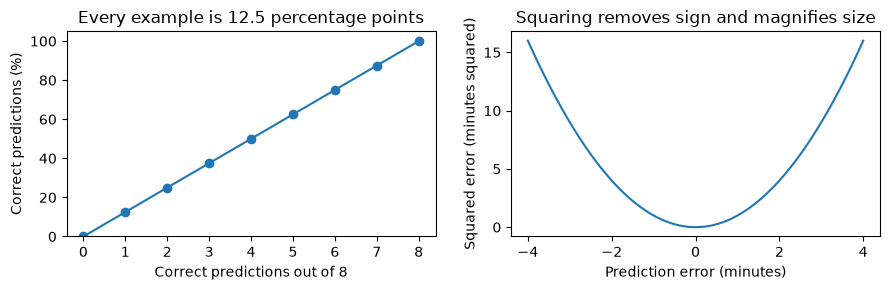

In [5]:
import matplotlib.pyplot as plt
counts = np.arange(9)
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(counts, 100 * counts / 8, marker='o')
axes[0].set(xlabel='Correct predictions out of 8', ylabel='Correct predictions (%)',
            title='Every example is 12.5 percentage points', xticks=counts, ylim=(0, 105))
grid = np.linspace(-4, 4, 81)
axes[1].plot(grid, grid ** 2)
axes[1].set(xlabel='Prediction error (minutes)', ylabel='Squared error (minutes squared)',
            title='Squaring removes sign and magnifies size')
fig.tight_layout()
display(fig)
plt.close(fig)

## 11. Experiment: equal percentages, different evidence

Three of four, six of eight, and seventy-five of one hundred all produce 75 percent. They do not contain the same number of observations. One changed answer shifts the first score by 25 percentage points, the second by 12.5, and the third by one. This is a sensitivity calculation, not a confidence interval.

In [6]:
sample_sizes = np.array([4, 8, 100])
correct_counts = np.array([3, 6, 75])
np.testing.assert_allclose(correct_counts / sample_sizes, 0.75)
one_example_changes = 100 / sample_sizes
np.testing.assert_allclose(one_example_changes, [25.0, 12.5, 1.0])
assert (2 * 2) ** 2 == 4 * (2 ** 2)
print('One changed prediction shifts percentage points by:', one_example_changes)

One changed prediction shifts percentage points by: [25.  12.5  1. ]


## 12. Choices and interpretation

The denominator, observation weights, and reporting scale must match the question. These are evaluation-definition choices, not learned model parameters. Rounding displayed percentages is reasonable for readability; retain sufficient precision internally. Changing from fractions to percentages changes presentation, not predictive performance. A starting value of zero prevents ordinary relative-change division and needs a different clearly stated comparison.

## 13. Evaluation

Check counts, bounds, denominator positivity, exact fraction equivalence, units, and agreement with an independently implemented score. For a proportion, $0\leq c\leq n$ should imply $0\leq p\leq1$. A finite number outside that range signals a broken count or a different statistic. For squared errors, verify nonnegativity and the factor-of-four effect when errors double.

The calculation is correct for the invented examples. It does not quantify uncertainty or prove future performance. Later evaluation lessons will explain splits, baselines, class imbalance, and uncertainty before using scores to choose models.

## 14. Assumptions and limitations

All counted examples have equal weight, and correctness has a clear binary definition. Real tasks may have different error costs, multi-label outcomes, or sample weights. Ordinary whole-number powers are only the beginning of exponent rules; fractional powers and logarithms require more domain care and have dedicated lessons. Floating-point overflow can occur for large powers even when the mathematical result exists.

## 15. Common mistakes and debugging

Do not report a percentage without its denominator or confuse percentage-point change with relative percent change. Do not average percentages from unequal sample sizes without weights when each observation should count equally. Do not use `^` for exponentiation. Put parentheses around negative bases when squaring. Check whether a displayed rounded value hides a meaningful difference before treating two results as exactly equal.

## 16. Alternatives and related ideas

Exact fractions clarify identities; decimal notation is convenient for numerical computation; percentages are familiar for reporting. Counts often reveal information that percentages hide. Absolute error preserves the original target units, whereas squared error emphasizes larger magnitudes. Later lessons compare losses according to the modeling objective rather than assuming one arithmetic operation is always best.

## 17. Exercises

- **Beginner:** Convert nine correct out of twelve to a simplified fraction, decimal, and percentage.
- **Beginner:** Calculate the squared error for prediction 2 and target 5 minutes.
- **Beginner:** Explain the difference between a ten-percentage-point increase and a ten-percent relative increase starting at 50 percent.
- **Intermediate:** Combine groups with three of four and one of six correct. Compare overall accuracy with the unweighted mean of group percentages.
- **Intermediate:** Show what tripling an error does to its squared error and explain the units.
- **Challenge:** Write a correct-percentage function that validates integer counts, rejects booleans and invalid denominators, and matches exact hand examples.

## 18. Detailed solutions

Nine twelfths simplifies to three quarters, decimal 0.75 and 75 percent. Error $2-5=-3$ minutes squares to nine minutes squared. Starting at 50 percent, ten percentage points gives 60 percent; ten percent relative growth adds five points and gives 55 percent. Combining groups gives four correct out of ten, or 40 percent. Averaging 75 and about 16.67 equally gives about 45.83 percent and incorrectly weights the groups for an observation-level question. Tripling an error multiplies its square by nine.

In [7]:
def correct_percentage(correct, total):
    if type(correct) is not int or type(total) is not int:
        raise TypeError('Counts must be ordinary integers, excluding bool.')
    if total <= 0 or correct < 0 or correct > total:
        raise ValueError('Require total > 0 and 0 <= correct <= total.')
    return 100 * correct / total

assert Fraction(9, 12) == Fraction(3, 4)
assert (2 - 5) ** 2 == 9
assert correct_percentage(4, 10) == 40.0
assert (3 * 2) ** 2 == 9 * (2 ** 2)
for correct, total in [(True, 8), (1.5, 8), (1, 0), (-1, 8), (9, 8)]:
    try:
        correct_percentage(correct, total)
    except (TypeError, ValueError):
        pass
    else:
        raise AssertionError('Invalid counts were accepted.')
assert correct_percentage(0, 8) == 0 and correct_percentage(8, 8) == 100
print('Fraction, squared-error, and validated-count exercises passed.')

Fraction, squared-error, and validated-count exercises passed.


## 19. Knowledge check

**What does a denominator specify?** The whole or reference quantity used in the comparison.

**What does percent mean?** A proportion expressed per hundred.

**Why is a zero denominator invalid?** Division cannot identify a unique finite ratio in that case.

**What happens when an error is squared?** Its sign disappears and its units are squared.

**Does 75 percent reveal sample size?** No. Many different counts can produce that percentage.

## 20. Interview preparation

**How do you combine group accuracies?** Weight by their observation counts when calculating an equally weighted per-observation score.

**Why distinguish relative changes from percentage points?** They use different reference scales and can imply substantially different improvements.

**Why use tolerance for floating-point comparison?** Binary representations and rounding can produce tiny differences from exact decimal arithmetic.

**Why does squared error emphasize large mistakes?** Multiplying error magnitude by a factor multiplies its square by that factor squared.

**Is a correct accuracy calculation a complete evaluation?** No. Sampling, baselines, class balance, error costs, and held-out performance still matter.

## 21. Summary and next steps

Fractions need clear denominators, percentages need clear interpretation, and powers need clear signs and units. Continue to [variables and equations](../../../02_Mathematics_for_ML/02_variables_and_equations.ipynb) to describe unknown quantities and solve simple relationships before fitting models.